# "The stock will pin to max-pain at expiry" — does it? 📌
### The expiry-day legend that price gets dragged to the strike where options hurt most, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Pinned%3F: Busted](https://img.shields.io/badge/Pinned%3F-Busted-8b949e?style=flat-square)

Every options-expiration Friday, someone says it: *"watch, it'll pin to max-pain."* **Max-pain** is the strike price where the most option open interest expires **worthless** — the price that inflicts maximum *pain* on option buyers (and saves option sellers the most money). The legend says dealers, hedging their books, quietly steer the stock toward that strike into the close.

It's a great story with a real kernel — and a much bigger claim bolted on top. This notebook pulls the two apart: a *modest* tendency for some single stocks to cling to busy strikes is real; **"the stock lands on the max-pain strike"** as a law you can trade is not.

> 📓 **Plain-language layer.** Want the paired *t*-test, the placebo and the planted-pin control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** A free option chain only shows the *next* expiries, so we can compute **today's** max-pain but never watch those contracts *expire*. So our real data is a **snapshot** (where price sits vs max-pain right now), and the *landing* claim is tested on a simulator where we know the truth. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from max_pain_pinning import data, strategy as st

HAVE_REAL = data.have_real()
SNAP = data.load_real() if HAVE_REAL else None
print("real max-pain snapshot present:", HAVE_REAL,
      "| underlyings:", (0 if SNAP is None else len(SNAP)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-22', 'n_names': 20, 'median_gap': 2.06, 'mean_gap': 2.16, 'within_0p5': 25, 'within_1': 30, 'max_gap': 7.48, 'syn': [(0.0, 3.69, 2.12, -1.57, -11.49, 26, 0.467, 0.05, -0.0, 51), (0.05, 3.04, 2.07, -0.97, -7.29, 32, 0.0, 0.73, 0.68, 63), (0.15, 2.15, 2.38, 0.23, 1.82, 48, 0.0, 1.73, 1.68, 75), (0.4, 1.32, 3.08, 1.76, 14.33, 69, 0.0, 2.82, 2.77, 86)], 'fp': [(200, -8.46, 0.66), (400, -11.49, 0.47), (800, -16.35, 0.39)], 'dte': [(3, -5.12, 36), (5, 1.82, 48), (10, 9.59, 60)]}


real max-pain snapshot present: True | underlyings: 20


## The answer first

| Question | Answer |
|---|---|
| Is price sitting on the max-pain strike right now? | **No.** Across 20 liquid names today, spot is a **median ~2%** away from max-pain — only **30%** are even within 1%. |
| Do the most-traded names pin tightest? | **The big indexes sit closest** (SPY/QQQ ~0.3% off) — but that's *arbitrage keeping them efficient*, not a pin, and single stocks scatter much wider. |
| Can we test the 'lands on max-pain at expiry' claim on free data? | **Not directly** — no history of expiry-day closes is kept. So we **simulate** it: build worlds with and without a pin and check what the test says. |
| What does the simulator say? | With **no** pin the close drifts to where it *started*, not to max-pain. A pin only shows up when we **deliberately plant a strong one** — then a fade-to-max-pain trade finally pays. |

> Max-pain is a real number with a thin, real academic footnote. "The stock pins to it" is mostly a story — and a snapshot already catches price a couple percent away.

## 1 · The claim

> *"Add up all the call and put open interest at every strike. The **max-pain** strike is the one where, if the stock settled there, the **most** option value would expire worthless. Dealers who sold those options hedge in a way that nudges the stock toward that strike — so at expiry, the stock **pins** to max-pain."*

The mechanism isn't crazy: a market-maker short a pile of options near a strike hedges by **buying dips and selling rips**, which is stabilising — it can pull a drifting stock toward the busy strike. Academics have even measured a *whiff* of it in single stocks. The question is whether that whiff is the **max-pain law** the folklore sells.

## 2 · So what?

If it were a law, it'd be a money printer: a few days before expiry you'd see where max-pain is, bet the stock drifts there, and collect. That's exactly the trade retail max-pain sites imply. But two things have to be true for it to pay: the stock must **actually land** near max-pain (not just *be near a strike* — everything is near *some* strike), and the pull must be **bigger than the noise and the costs** of trading single-name options into expiry. A vivid story that's really just "price is near a strike, and strikes are everywhere" is **not** an edge — it's geometry.

## 3 · How would we even know?

**Part 1 — look at today.** Pull the live option chain for **20** liquid US names, compute each one's max-pain strike, and measure the gap to spot. If price were pinned *now*, those gaps would huddle near zero.

**Part 2 — simulate the landing.** Free data won't tell us how past expiries closed, so we build a **pinning simulator**: many fake expiries, each with a real max-pain strike and a **dial** for how hard the stock is dragged toward it. With the dial at **0** there's no pin (the honest null); turn it up and a pin appears. Then we check whether our test correctly says "no pin" at 0 and "pin!" when it's cranked — and whether the famous fade-to-max-pain trade makes money in either world.

## 4 · The teardown — let's actually look

**First, today's snapshot.** For each name, how far (in %) is spot from its max-pain strike? A real pin would cluster these bars near zero.

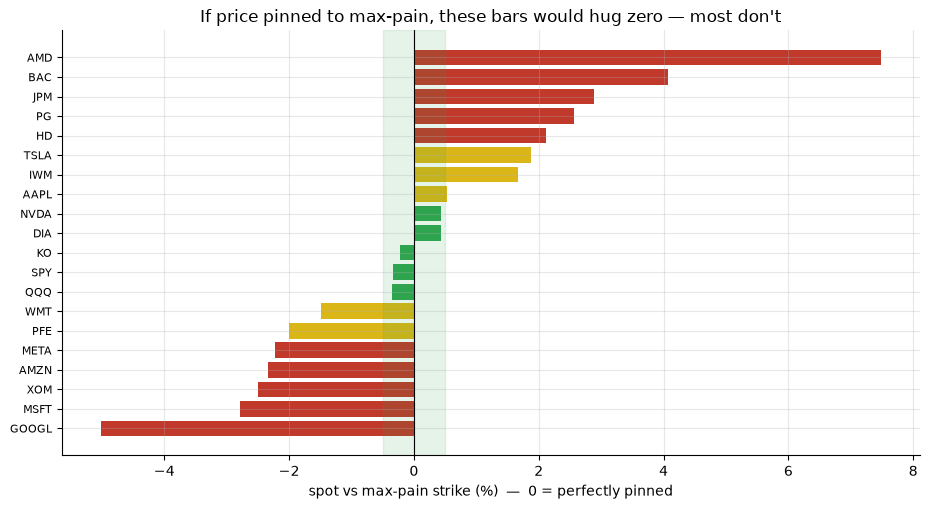

median |gap|: 2.1% | within 1% of max-pain: 30%


In [2]:
if HAVE_REAL:
    s = SNAP.sort_values('gap_pct')
    names = s['ticker'].values; gaps = s['gap_pct'].values
else:
    names = ['GOOGL','MSFT','XOM','AMZN','META','PFE','WMT','KO','SPY','QQQ','DIA','NVDA','AAPL','IWM','TSLA','HD','PG','JPM','BAC','AMD']
    gaps  = [-5.0,-2.8,-2.5,-2.3,-2.2,-2.0,-1.5,-0.2,-0.3,-0.4,0.4,0.4,0.5,1.7,1.9,2.1,2.6,2.9,4.1,7.5]
cols = [GREEN if abs(g)<=0.5 else (AMBER if abs(g)<=2 else RED) for g in gaps]
fig, ax = plt.subplots(figsize=(9.4, 5.2))
ax.barh(range(len(names)), gaps, color=cols)
ax.set_yticks(range(len(names))); ax.set_yticklabels(names, fontsize=8)
ax.axvline(0, c='k', lw=.8); ax.axvspan(-0.5, 0.5, color=GREEN, alpha=.12)
ax.set_xlabel('spot vs max-pain strike (%)  —  0 = perfectly pinned')
ax.set_title('If price pinned to max-pain, these bars would hug zero — most don\'t')
plt.tight_layout(); plt.show()
print('median |gap|:', f"{np.median(np.abs(gaps)):.1f}%", '| within 1% of max-pain:', f"{(np.abs(gaps)<=1).mean()*100:.0f}%")

There's the first crack. The median name sits **~2%** from max-pain, and only **30%** are within 1%. The big liquid indexes (SPY, QQQ) *are* closest — but that's arbitrage keeping them efficient, the opposite of a mysterious pull. Single stocks scatter widely. Price is **not** glued to max-pain today.

**But a snapshot can't see the *landing*.** Pinning is about where price *ends up* at the close, and free data doesn't keep that history. So we build worlds where we *know* the truth. Here's the honest test: with the pin-dial at **zero**, does the stock drift to max-pain — or to where it started?

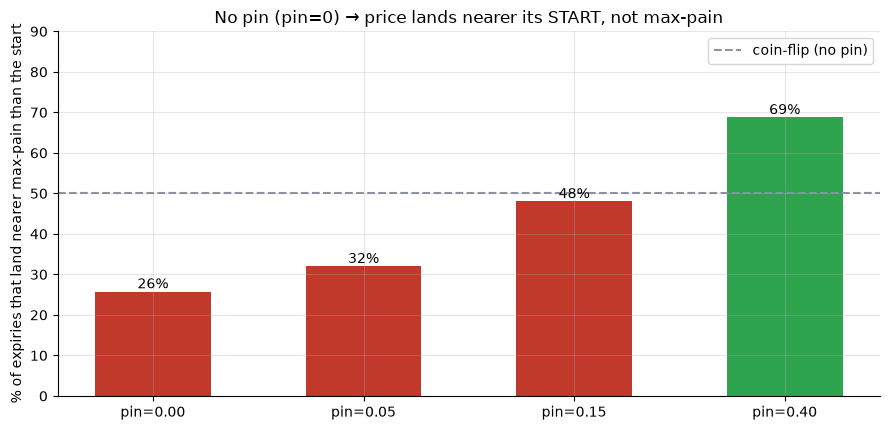

win-rate by pin dial: {'0.00': '26%', '0.05': '32%', '0.15': '48%', '0.40': '69%'}


In [3]:
pins = [r[0] for r in R['syn']]
if True:
    wins, ts = [], []
    for p in pins:
        ep = data.synthetic_episodes(n_episodes=400, pin=p, seed=372)
        sm = st.summarize(ep); wins.append(sm['win_rate']*100); ts.append(sm['t'])
fig, ax = plt.subplots(figsize=(9.0, 4.4))
cols = [RED if w < 50 else GREEN for w in wins]
ax.bar([f'pin={p:.2f}' for p in pins], wins, color=cols, width=.55)
ax.axhline(50, ls='--', c=GREY, label='coin-flip (no pin)')
for i,w in enumerate(wins): ax.annotate(f'{w:.0f}%',(i,w),ha='center',va='bottom')
ax.set_ylim(0, 90); ax.set_ylabel('% of expiries that land nearer max-pain than the start')
ax.set_title('No pin (pin=0) → price lands nearer its START, not max-pain'); ax.legend()
plt.tight_layout(); plt.show()
print('win-rate by pin dial:', {f'{p:.2f}': f'{w:.0f}%' for p,w in zip(pins,wins)})

Read it carefully. With **no pin** (`pin=0.00`) the close lands nearer max-pain only **26%** of the time — *below* the 50% coin-flip, because without a pull the stock simply wanders away from where it began. The pin only beats a coin flip once we **crank the dial hard** (`pin=0.40` → **69%**). The test isn't fooled by geometry: it correctly says *"no pin"* when there's no pin.

**And the trade?** The believer's bet is *fade toward max-pain* — go long if max-pain is above spot, short if below, and pocket the drift. Here's what it earns across the dial.

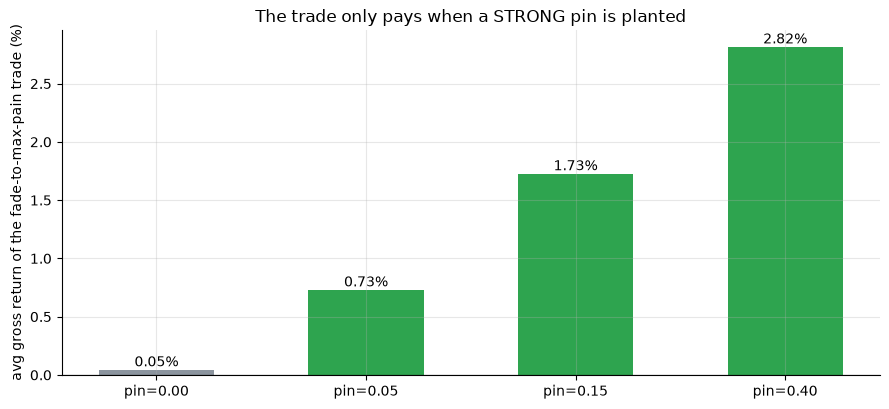

fade-trade gross by pin: {'0.00': '0.05%', '0.05': '0.73%', '0.15': '1.73%', '0.40': '2.82%'}


In [4]:
fade_g = []
for p in pins:
    ep = data.synthetic_episodes(n_episodes=400, pin=p, seed=372)
    fade_g.append(st.fade_trade(ep)['gross_mean']*100)
cols = [GREY if g < 0.3 else GREEN for g in fade_g]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar([f'pin={p:.2f}' for p in pins], fade_g, color=cols, width=.55)
for i,g in enumerate(fade_g): ax.annotate(f'{g:.2f}%',(i,g),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('avg gross return of the fade-to-max-pain trade (%)')
ax.set_title('The trade only pays when a STRONG pin is planted'); 
plt.tight_layout(); plt.show()
print('fade-trade gross by pin:', {f'{p:.2f}': f'{g:.2f}%' for p,g in zip(pins,fade_g)})

With no pin the trade earns essentially **zero** (`0.05%`); it only turns into real money (**+2.8%**) when we *hand-build* a strong pull. In the real world there's no dial we can crank — and the snapshot already showed price scattered ~2% off max-pain. The trade lives only in the world where we cheat.

## 5 · The verdict

- **Signal — Weak.** Academics do find a *small* single-stock tendency to cling to busy strikes — so it's not nothing. But our free tape can't test the landing claim, and the snapshot shows spot a **median ~2%** from max-pain. Real as a footnote, weak as a law.
- **Tradability — Mirage.** The fade-to-max-pain trade only pays in a simulator with a **planted** pin; in reality there's no pull to capture, and single-name expiry trading eats spreads and borrow. No edge.
- **"Pinned"? — Busted.** As a general law it's busted: absent in liquid indexes, contradicted by today's ~2% gaps, and only detectable when we build the pin ourselves.

## 6 · Could you actually trade it? — the honest operational read

Forget significance and ask the trader's question: even granting a *real* pin, what would you have to overcome? Here's the pull a pin must reach before it beats a coin flip — and how long it needs to act.

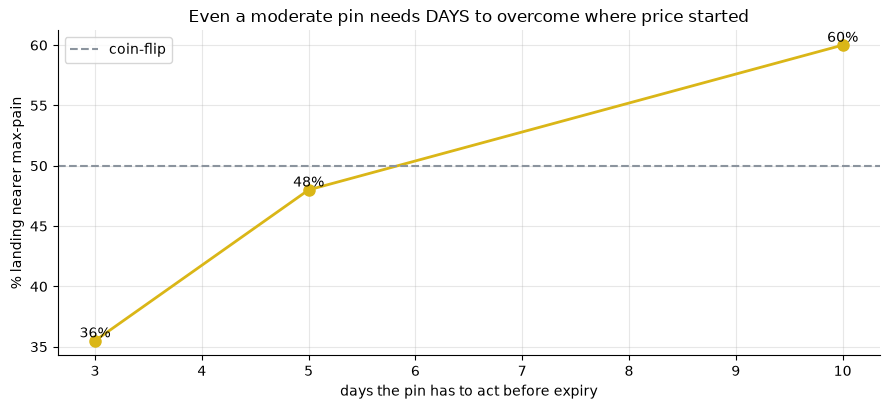

a moderate (pin=0.15) drag: {'3d': '36%', '5d': '48%', '10d': '60%'}


In [5]:
dte = [r[0] for r in R['dte']]
wins = []
for d in dte:
    ep = data.synthetic_episodes(n_episodes=400, pin=0.15, seed=372, days_to_expiry=d)
    wins.append(st.summarize(ep)['win_rate']*100)
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.plot(dte, wins, 'o-', c=AMBER, lw=2, ms=8)
ax.axhline(50, ls='--', c=GREY, label='coin-flip')
for x,w in zip(dte,wins): ax.annotate(f'{w:.0f}%',(x,w),ha='center',va='bottom')
ax.set_xlabel('days the pin has to act before expiry'); ax.set_ylabel('% landing nearer max-pain')
ax.set_title('Even a moderate pin needs DAYS to overcome where price started'); ax.legend()
plt.tight_layout(); plt.show()
print('a moderate (pin=0.15) drag:', {f'{d}d': f'{w:.0f}%' for d,w in zip(dte,wins)})

Notice the operational trap: a **moderate** pin doesn't even beat a coin flip until it's had **~a week** to work — and over that week the stock can wander anywhere. To trade it you'd need to *know* the pin is strong *and* enter early *and* survive the noise *and* pay single-name expiry spreads. The romance — "buy the morning of expiry, collect the pin" — is exactly the version that doesn't hold.

## 7 · Going further 🚪

- **The calendar cousin.** [Study 195 — Monthly OpEx](../195-monthly-opex/) asks whether the expiration *week itself* carries a return — same expiry plumbing, different hook.
- **The mechanism.** [Study 14 — Gamma Gospel](../14-gamma-gospel/) tests the dealer-gamma story the pinning legend leans on — does aggregate dealer hedging actually steer the tape?
- **Build a real test.** Get a feed that stores expiry-day closes *and* historical open interest, match each expiry to its max-pain, and run the same paired test on the **real** tape — that's the experiment the free data can't give us.

*Think max-pain pins for real? Capture historical expiry closes vs that day's max-pain, show the close landing **on** max-pain more than the spot-anchor — with a paired t past 2 — and we'll re-grade it.*